In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## Computational environment and software versions
Records the Python and library versions used, for reproducibility and the operational-cost reporting in the manuscript.

In [2]:
import sys, platform
import numpy, xarray, matplotlib
print("Python      :", sys.version.split()[0])
print("Platform    :", platform.platform())
print("Processor   :", platform.processor())
print("numpy       :", numpy.__version__)
print("xarray      :", xarray.__version__)
print("matplotlib  :", matplotlib.__version__)
try:
    import netCDF4; print("netCDF4     :", netCDF4.__version__)
except Exception: pass
try:
    import h5netcdf; print("h5netcdf    :", h5netcdf.__version__)
except Exception: pass

Python      : 3.13.9
Platform    : Windows-11-10.0.26100-SP0
Processor   : Intel64 Family 6 Model 181 Stepping 0, GenuineIntel
numpy       : 2.3.5
xarray      : 2025.10.1
matplotlib  : 3.10.6
netCDF4     : 1.7.4
h5netcdf    : 1.8.1


Load Data

In [3]:
STNS = np.loadtxt("../DATA/Stations.txt",dtype='U2')
VNS = np.loadtxt("../DATA/Products.txt",dtype='<U10')

STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_ERR = xr.open_dataarray("../DATA/STN_ERR.nc")

STN_AB = xr.open_dataarray("../DATA/STN_AB.nc")
STN_AB_ERR = xr.open_dataarray("../DATA/STN_AB_ERR.nc")

## Input data volume
Total on-disk size of the inputs consumed by the COM stage (8-day ET estimates, error fields, and the AB outputs from the previous notebook).

In [4]:
import os
files = ["STN_DATA.nc", "STN_ERR.nc", "STN_AB.nc", "STN_AB_ERR.nc"]
total = 0.0
for f in files:
    p = os.path.join("../DATA", f)
    if os.path.exists(p):
        sz = os.path.getsize(p) / 1e6
        total += sz
        print(f"{f:14s} {sz:8.2f} MB")
print(f"{'TOTAL':14s} {total:8.2f} MB")

STN_DATA.nc        0.57 MB
STN_ERR.nc         0.57 MB
STN_AB.nc          0.47 MB
STN_AB_ERR.nc      0.47 MB
TOTAL              2.07 MB


Drop PM and TH Products

In [5]:
O = STN_DATA.loc[dict(Product="PM")]
REMOTE = STN_DATA.drop_sel(Product=["PM", "TH"])
ERR_REMOTE = STN_ERR.drop_sel(Product=["PM", "TH"])

Calculate RMSE scores

In [6]:
STN_RMSE = np.sqrt((ERR_REMOTE**2).mean(dim="datetime"))
STN_AB_RMSE = np.sqrt((STN_AB_ERR**2).mean(dim="datetime"))

Calculate weights for the COM method.

$$
\begin{align}
err_i &= (1/N) \sum_{j=1}^N err_{(i-j)}^2 \\
w_i &= \frac{1/err_i}{\sum_{i=1}^{10}(1/err_i)} \\
MSECOM &= \sum_{i=1}^{10} w_i AB_i
\end{align}
$$

Calculate COM

The datetime stamps are from the most recent of the dates which have been used.

COM needs to use the weights from the previous date.

wCOM =  1, RMSE = 2.2245
wCOM =  2, RMSE = 1.6899
wCOM =  3, RMSE = 1.5619
wCOM =  4, RMSE = 1.5055
wCOM =  5, RMSE = 1.4697
wCOM =  6, RMSE = 1.4622
wCOM =  7, RMSE = 1.4581
wCOM =  8, RMSE = 1.4561
wCOM =  9, RMSE = 1.4597
wCOM = 10, RMSE = 1.4625
wCOM = 11, RMSE = 1.4617
wCOM = 12, RMSE = 1.4634
wCOM = 13, RMSE = 1.4701
wCOM = 14, RMSE = 1.4778
wCOM = 15, RMSE = 1.4797
wCOM = 16, RMSE = 1.4814
wCOM = 17, RMSE = 1.4845
wCOM = 18, RMSE = 1.4827
wCOM = 19, RMSE = 1.4822
wCOM = 20, RMSE = 1.4284
wCOM = 21, RMSE = 1.4245
wCOM = 22, RMSE = 1.4218
wCOM = 23, RMSE = 1.4186
wCOM = 24, RMSE = 1.4050
wCOM = 25, RMSE = 1.4079
wCOM = 26, RMSE = 1.4003
wCOM = 27, RMSE = 1.4014
wCOM = 28, RMSE = 1.4000
wCOM = 29, RMSE = 1.4000
wCOM = 30, RMSE = 1.3992

Minimum RMSE window: wCOM = 30, RMSE = 1.3992
Chosen practical window: wCOM = 8, RMSE = 1.4561



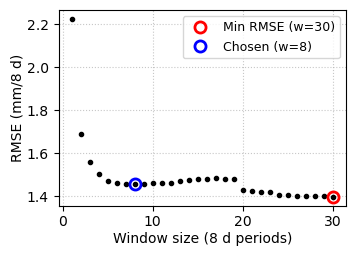

In [7]:
# Set up the figure
fig = plt.figure(figsize=(3.5, 2.5))
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

rmse_values = []
window_sizes = list(range(1, 31))

for wCOM in window_sizes:
    MSE_AB = (STN_AB_ERR**2).rolling(datetime=wCOM, center=False).mean()
    MSE_ABm = (1 / MSE_AB).sum(dim="Product")
    wi = (1 / MSE_AB) / MSE_ABm

    STN_AB1 = STN_AB[:, :, wCOM:]         
    wi1 = wi[:, :, wCOM-1:-1]              
    STN_COM = (STN_AB1 * wi1.values).sum(dim="Product")

    i_d1 = STN_COM.datetime[0].values
    i_dn = STN_COM.datetime[-1].values
    STN_COM_ERR = STN_COM - O.sel(datetime=slice(i_d1, i_dn))

    COM_RMSE = np.sqrt((STN_COM_ERR**2).mean(dim="datetime")) 
    rmse_mean = float(COM_RMSE.mean().values)                  

    rmse_values.append(rmse_mean)

    # smaller black markers
    plt.plot(wCOM, rmse_mean, 'ko', markersize=3)

    print(f"wCOM = {wCOM:2d}, RMSE = {rmse_mean:.4f}")

# ---- Circle the minimum RMSE window ----
best_idx = int(np.argmin(rmse_values))
best_wCOM = window_sizes[best_idx]
best_rmse = rmse_values[best_idx]

plt.plot(best_wCOM, best_rmse, marker='o', linestyle='None',
         markerfacecolor='none', markeredgecolor='red',
         markeredgewidth=2, markersize=8, zorder=5,
         label=f"Min RMSE (w={best_wCOM})")

# ---- Also circle wCOM = 8 ----
w_practical = 8
if w_practical in window_sizes:
    rmse_8 = rmse_values[window_sizes.index(w_practical)]
    plt.plot(w_practical, rmse_8, marker='o', linestyle='None',
             markerfacecolor='none', markeredgecolor='blue',
             markeredgewidth=2, markersize=8, zorder=5,
             label="Chosen (w=8)")

plt.legend(loc="best", fontsize=9)

# Customize grid and ticks
plt.xticks(ticks=range(0, 31, 10))
plt.grid(True, linestyle=':', alpha=0.7)

# Axis labels
plt.ylabel("RMSE (mm/8 d)", labelpad=2)
plt.xlabel("Window size (8 d periods)", labelpad=2)

# Adjust layout and save
plt.tight_layout(pad=0.5)
plt.savefig("WindowSize_COM.png", dpi=300, bbox_inches='tight')

print("\n" + "="*50)
print(f"Minimum RMSE window: wCOM = {best_wCOM}, RMSE = {best_rmse:.4f}")
print(f"Chosen practical window: wCOM = 8, RMSE = {rmse_8:.4f}")
print("="*50 + "\n")


## Calibration cost — COM window sweep (one-time)
Times the full `w = 1..30` sweep used to select the COM window (Figure 5). This is a **one-time calibration cost** (setup or recalibration), not the recurring operational cost.

In [8]:
import time
import numpy as np

N_REPEATS = 5
com_sweep_times = []
for rep in range(N_REPEATS):
    t0 = time.perf_counter()
    rmse_values = []
    for wCOM in range(1, 31):
        MSE_AB  = (STN_AB_ERR**2).rolling(datetime=wCOM, center=False).mean()
        MSE_ABm = (1/MSE_AB).sum(dim="Product")
        wi      = (1/MSE_AB)/MSE_ABm
        STN_AB1 = STN_AB[:, :, wCOM:]
        wi1     = wi[:, :, wCOM-1:-1]
        STN_COM = (STN_AB1*wi1.values).sum(dim="Product")
        i_d1    = STN_COM.datetime[0].values
        i_dn    = STN_COM.datetime[-1].values
        STN_COM_ERR = STN_COM - O.sel(datetime=slice(i_d1, i_dn))
        rmse_values.append(float(np.sqrt((STN_COM_ERR**2).mean(dim="datetime")).mean().values))
    com_sweep_times.append(time.perf_counter() - t0)

com_sweep_times = np.array(com_sweep_times)
print(f"COM window sweep (w=1..30), {N_REPEATS} repeats:")
print(f"  mean  = {com_sweep_times.mean():.3f} s")
print(f"  range = [{com_sweep_times.min():.3f}, {com_sweep_times.max():.3f}] s")

COM window sweep (w=1..30), 5 repeats:
  mean  = 0.365 s
  range = [0.245, 0.439] s


## Production cost — COM computation (recurring, wCOM=8)
Times the operational COM path at the chosen window `wCOM=8`. This is the **recurring per-update cost**, scoped to the COM computation itself (AB outputs are already loaded; upstream extraction/aggregation excluded).

In [9]:
import time
import numpy as np

N_REPEATS = 5
com_times = []
for rep in range(N_REPEATS):
    t0 = time.perf_counter()
    wCOM = 8
    MSE_AB  = (STN_AB_ERR**2).rolling(datetime=wCOM, center=False).mean()
    MSE_ABm = (1/MSE_AB).sum(dim="Product")
    wi      = (1/MSE_AB)/MSE_ABm
    STN_AB1 = STN_AB[:, :, wCOM:]
    wi1     = wi[:, :, wCOM-1:-1]
    STN_COM = (STN_AB1*wi1.values).sum(dim="Product")
    i_d1    = STN_COM.datetime[0].values
    i_dn    = STN_COM.datetime[-1].values
    STN_COM_ERR = STN_COM - O.sel(datetime=slice(i_d1, i_dn))
    com_times.append(time.perf_counter() - t0)

com_times = np.array(com_times)
n_stn = len(STNS)
print(f"COM production (wCOM=8), {N_REPEATS} repeats:")
print(f"  mean        = {com_times.mean()*1000:.1f} ms")
print(f"  range       = [{com_times.min()*1000:.1f}, {com_times.max()*1000:.1f}] ms")
print(f"  per station = {com_times.mean()/n_stn*1000:.2f} ms  (n={n_stn} stations)")

COM production (wCOM=8), 5 repeats:
  mean        = 12.3 ms
  range       = [9.1, 13.5] ms
  per station = 0.58 ms  (n=21 stations)


In [10]:
wCOM=8
MSE_AB = (STN_AB_ERR**2).rolling(datetime=wCOM, center=False).mean()
MSE_ABm = (1/MSE_AB).sum(dim="Product")
wi = (1/MSE_AB)/MSE_ABm
STN_AB1 = STN_AB[:,:,wCOM:] 
wi1 = wi[:,:,wCOM-1:-1] 
STN_COM = (STN_AB1*wi1.values).sum(dim="Product") 
i_d1=STN_COM.datetime[0].values 
i_dn=STN_COM.datetime[-1].values
STN_COM_ERR = STN_COM - O.sel(datetime=slice(i_d1, i_dn)) 
COM_RMSE = np.sqrt((STN_COM_ERR**2).mean(dim="datetime")) 


In [11]:
STN_COM.to_netcdf("../DATA/STN_COM.nc")
STN_COM_ERR.to_netcdf("../DATA/STN_COM_ERR.nc")

In [12]:
O_C = O.sel(datetime=slice(i_d1, i_dn))
R_C = REMOTE.sel(datetime=slice(i_d1, i_dn))
AB_C = STN_AB.sel(datetime=slice(i_d1, i_dn))
COM_C = STN_COM.sel(datetime=slice(i_d1, i_dn))

In [13]:
R_E = R_C - O_C
AB_E = AB_C - O_C
COM_E = COM_C - O_C 

In [14]:
print("R RMSE = ", np.sqrt((R_E.sel(Product="LSA")**2).mean(dim="datetime")).mean().values)
print("AB RMSE = ", np.sqrt((AB_E.sel(Product="LSA")**2).mean(dim="datetime")).mean().values)
print("COM RMSE = ",np.sqrt((COM_E**2).mean(dim="datetime")).mean().values)

R RMSE =  3.0911626115332664
AB RMSE =  1.5257428283466885
COM RMSE =  1.4560787468303131


## Peak memory — COM production stage
Measures peak Python-level memory for the operational COM computation. **Run this after a fresh kernel restart** (run the import, Load Data, Drop, and RMSE cells first, then this) so the measurement is not inflated by the timing loops above.

In [15]:
import tracemalloc
import numpy as np

tracemalloc.start()

wCOM = 8
MSE_AB  = (STN_AB_ERR**2).rolling(datetime=wCOM, center=False).mean()
MSE_ABm = (1/MSE_AB).sum(dim="Product")
wi      = (1/MSE_AB)/MSE_ABm
STN_AB1 = STN_AB[:, :, wCOM:]
wi1     = wi[:, :, wCOM-1:-1]
STN_COM = (STN_AB1*wi1.values).sum(dim="Product")
i_d1    = STN_COM.datetime[0].values
i_dn    = STN_COM.datetime[-1].values
STN_COM_ERR = STN_COM - O.sel(datetime=slice(i_d1, i_dn))

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"COM stage current allocation: {current/1e6:.1f} MB")
print(f"COM stage peak memory       : {peak/1e6:.1f} MB")

COM stage current allocation: 1.5 MB
COM stage peak memory       : 2.9 MB
